# VLST — TabPFN (tabular foundation model)

## Overview

**TabPFN** ([PriorLabs TabPFN](https://github.com/PriorLabs/TabPFN)) is a transformer-style model trained on synthetic tabular tasks; at **inference** time it performs **in-context learning** on your training rows (no classical hyperparameter grid search). It is often strong on **small/medium** tabular problems, including **imbalanced** settings when using built-in options such as **`balance_probabilities`**.

This notebook is aligned with **`baseline_without_tssi.ipynb`**:

- **Data**: `data/processed/` under the VLST repo (`X_train.npy`, …) from **`preprocessing.ipynb`**. Paths are **auto-detected** from the kernel’s current working directory (works when cwd is `Downloads`, `vlst_repo/code`, etc.). Override with **`MANUAL_VLST_ROOT`** in §2 if needed.
- **Leakage control**: drops **`Time since stent implantation`** (same as other modeling notebooks)
- **Optional SMOTE**: same toggle as baselines (default **off**; TabPFN already targets imbalance via probabilities)
- **Outputs**: metrics and plots under **`../data/result/modeling_tabpfn/`**. Filenames include a **per-run tag** (UTC time + `balance_probabilities`) so repeated runs do not overwrite; set env **`TABPFN_RESULT_TAG=my_label`** to choose the tag yourself.

### Important notes

1. **Kernel / install**: One-time from the repo root run **`bash scripts/setup_notebook_venv.sh`** (creates **`.venv`**, installs **`requirements.txt`** + **`ipykernel`**, registers Jupyter **Python (vlst .venv)**). In Cursor/VS Code choose that kernel or interpreter **`.venv/bin/python`**, then run §1 (it refuses system Python so you avoid PEP 668 errors).
2. **Preprocessing**: TabPFN’s docs often recommend feeding **raw** tabular data and letting the model preprocess. Here we default to the **same scaled / one-hot matrices** as the rest of your pipeline so results are **comparable** to XGBoost/LightGBM notebooks. Set **`USE_RAW_FEATURES = True`** below to build features from **`../data/raw/VLST.csv`** with a **stratified split** (same `random_state` as `preprocessing.ipynb`) — scores will **not** match other notebooks exactly, but inputs are closer to TabPFN’s intended use.
3. **Size / CPU**: Training sets larger than typical pretraining ranges may require **`ignore_pretraining_limits=True`** (set below). On CPU, very large train sets can be impractical.
4. **Cross-validation**: Fitting TabPFN per fold is **expensive**. Optional stratified CV is **off** by default; enable **`RUN_TABPFN_CV`** when you can afford the runtime.

## 1. Install TabPFN (run once per environment)

If the kernel **Python (vlst .venv)** is not listed yet, use **Select Another Kernel → Python Environments** and choose the **`.venv`** at the repository root, or run the setup script below first.

In [1]:
import subprocess
import sys
from pathlib import Path


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "requirements.txt").is_file():
            return d
    raise RuntimeError(
        "Could not find requirements.txt. Run the notebook with cwd inside the VLST repo, "
        "or cd to the repo root and try again."
    )


def _in_virtualenv() -> bool:
    return sys.prefix != getattr(sys, "base_prefix", sys.prefix)


if not _in_virtualenv():
    raise RuntimeError(
        "Not running in a virtual environment (PEP 668 blocks pip on system Python).\n\n"
        "From the VLST repo root, run once:\n"
        "  bash scripts/setup_notebook_venv.sh\n"
        "Then select kernel **Python (vlst .venv)** or interpreter **.venv/bin/python**, and re-run this cell."
    )

req = _repo_root() / "requirements.txt"
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(req)],
    cwd=str(_repo_root()),
)
print("OK:", req)

OK: /home/fadia/Documents/vlst/requirements.txt


## 2. Configuration

In [16]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

# If auto-discovery fails, set this to your clone root (folder that contains data/raw/ and data/processed/).
MANUAL_VLST_ROOT: Path | None = None  # e.g. Path("/home/you/Downloads/vlst_repo")


def _resolve_processed_dir() -> Path:
    if MANUAL_VLST_ROOT is not None:
        p = Path(MANUAL_VLST_ROOT).expanduser().resolve() / "data" / "processed"
        if (p / "X_train.npy").is_file():
            return p
        raise FileNotFoundError(
            f"MANUAL_VLST_ROOT set but missing {p / 'X_train.npy'} — run preprocessing.ipynb first."
        )
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents][:14]:
        for parts in (("data", "processed"), ("vlst_repo", "data", "processed")):
            cand = root.joinpath(*parts)
            if (cand / "X_train.npy").is_file():
                return cand
    raise FileNotFoundError(
        "Could not find data/processed/X_train.npy. Typical fixes: (1) Run code/preprocessing.ipynb "
        "to create vlst_repo/data/processed/. (2) Set MANUAL_VLST_ROOT to your vlst_repo path. "
        f"(3) Set USE_RAW_FEATURES=True if ../data/raw/VLST.csv exists. Current cwd: {cwd}"
    )


PROCESSED_DIR = _resolve_processed_dir()
DATA_ROOT = PROCESSED_DIR.parent.parent  # .../vlst_repo
RAW_PATH = DATA_ROOT / "data" / "raw" / "VLST.csv"
RESULT_DIR = DATA_ROOT / "data" / "result" / "modeling_tabpfn"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using PROCESSED_DIR={PROCESSED_DIR}")
print(f"Using RESULT_DIR={RESULT_DIR}")

TARGET_COL = "Stent thrombosis"
DROP_FEATURES = ["Time since stent implantation"]
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Match preprocessing.ipynb split when rebuilding from raw
USE_RAW_FEATURES = False  # True: TabPFN-style raw table + same random_state split

USE_SMOTE = False  # True requires imbalanced-learn (§1)
IGNORE_PRETRAINING_LIMITS = True  # needed for n_train outside default pretraining range / CPU limits
BALANCE_PROBABILITIES = False  # helps under strong class imbalance (VLST)
DEVICE = "auto"  # "cuda", "cpu", or "auto"
N_ESTIMATORS = 8  # TabPFN ensemble of forward passes (not traditional trees)

# P(class=1) threshold for y_pred. None = pick threshold by max F1 on a stratified val slice of train, then refit on full train.
DECISION_THRESHOLD: float | None = None  # e.g. 0.5 to match clf.predict() default
THRESHOLD_VAL_FRACTION = 0.15  # only used when DECISION_THRESHOLD is None

RUN_TABPFN_CV = True  # True: stratified K-fold (slow)
CV_SPLITS = 3

from datetime import datetime, timezone

# Unique stem for this run (re-run §2 after toggling BALANCE_PROBABILITIES to compare without overwrite).
TABPFN_RESULT_TAG = os.environ.get(
    "TABPFN_RESULT_TAG",
    f"{datetime.now(timezone.utc):%Y%m%dT%H%M%S}_bal{BALANCE_PROBABILITIES}",
)


def tabpfn_result_path(filename: str) -> Path:
    p = Path(filename)
    return RESULT_DIR / f"{p.stem}_{TABPFN_RESULT_TAG}{p.suffix}"


print(f"TabPFN output tag: {TABPFN_RESULT_TAG}")

Using PROCESSED_DIR=/home/fadia/Documents/vlst/data/processed
Using RESULT_DIR=/home/fadia/Documents/vlst/data/result/modeling_tabpfn
TabPFN output tag: 20260412T142759_balFalse


## 3. Load data (processed or raw)

In [12]:
def drop_tssi_from_arrays(X_tr, X_te, feature_names_list):
    fn = np.array(feature_names_list)
    drop_mask = np.isin(fn, DROP_FEATURES)
    if not drop_mask.any():
        raise ValueError(
            f"None of {DROP_FEATURES} found in feature_names; check feature_names.csv."
        )
    keep = ~drop_mask
    return X_tr[:, keep], X_te[:, keep], fn[keep].tolist()


if not USE_RAW_FEATURES:
    X_train = np.load(PROCESSED_DIR / "X_train.npy")
    X_test = np.load(PROCESSED_DIR / "X_test.npy")
    y_train = np.load(PROCESSED_DIR / "y_train.npy")
    y_test = np.load(PROCESSED_DIR / "y_test.npy")
    feature_names = pd.read_csv(PROCESSED_DIR / "feature_names.csv")[
        "feature_name"
    ].tolist()
    X_train, X_test, feature_names = drop_tssi_from_arrays(
        X_train, X_test, feature_names
    )
    print("Using preprocessed .npy arrays (comparable to other modeling notebooks).")
else:
    if not RAW_PATH.is_file():
        raise FileNotFoundError(
            f"Raw CSV not found: {RAW_PATH}. Place VLST.csv there or set USE_RAW_FEATURES=False "
            "and run preprocessing.ipynb."
        )
    df = pd.read_csv(RAW_PATH)
    for col in ("NO.", "Name"):
        if col in df.columns:
            df = df.drop(columns=[col])
    y = df[TARGET_COL].values
    X_df = df.drop(columns=[TARGET_COL])
    X_df = X_df.apply(pd.to_numeric, errors="ignore")
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
    for c in cat_cols:
        X_df[c] = pd.Categorical(X_df[c].astype("string").fillna("__nan__")).codes
    for c in [x for x in DROP_FEATURES if x in X_df.columns]:
        X_df = X_df.drop(columns=[c])
    X_raw = np.nan_to_num(X_df.values.astype(np.float64), nan=0.0)
    feature_names = list(X_df.columns)
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    print("Using raw-derived numeric matrix + stratified split (TabPFN-oriented).")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {len(feature_names)}")
print(
    f"Train target: 0={np.sum(y_train == 0)}, 1={np.sum(y_train == 1)} | "
    f"Test: 0={np.sum(y_test == 0)}, 1={np.sum(y_test == 1)}"
)

Using preprocessed .npy arrays (comparable to other modeling notebooks).
Train: (4148, 173), Test: (1037, 173)
Features: 173
Train target: 0=4074, 1=74 | Test: 0=1019, 1=18


## 4. Optional SMOTE (training set only)

In [13]:
import importlib

X_train_before_smote = X_train.copy()
y_train_before_smote = y_train.copy()

if USE_SMOTE:
    try:
        _smote_mod = importlib.import_module("imblearn.over_sampling")
        SMOTE = getattr(_smote_mod, "SMOTE")
    except (ImportError, AttributeError) as e:
        raise ImportError(
            "USE_SMOTE=True requires imbalanced-learn. Run §1 in a venv: "
            '%pip install imbalanced-learn'
        ) from e

    n_minority = (y_train == 1).sum()
    k = min(5, n_minority - 1) if n_minority > 1 else 1
    if k < 1:
        print("SMOTE skipped: minority class too small.")
    else:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        print(
            f"SMOTE applied: train -> {X_train.shape[0]} rows "
            f"(0={(y_train == 0).sum()}, 1={(y_train == 1).sum()})"
        )
else:
    print("SMOTE off (recommended default for TabPFN).")

SMOTE off (recommended default for TabPFN).


In [14]:
import os

# PriorLabs TabPFN: do not hard-code API keys in the notebook (git leak risk).
if not os.environ.get("TABPFN_TOKEN"):
    raise RuntimeError(
        "Missing TABPFN_TOKEN. Export it in the shell, e.g. export TABPFN_TOKEN='...', "
        "or set os.environ['TABPFN_TOKEN'] in a local-only cell before §5."
    )
print("TABPFN_TOKEN is set (value hidden).")

TABPFN_TOKEN is set (value hidden).


## 5. Fit TabPFN and evaluate (hold-out)

`clf.predict()` uses TabPFN’s default threshold (often 0.5). For strong imbalance, **`DECISION_THRESHOLD = None`** (default) tunes the threshold on a **stratified holdout slice of the training set** to maximize **F1** for the positive class, then refits on **all** training rows before scoring the test set. Set **`DECISION_THRESHOLD = 0.5`** to match the default `predict()` behavior. **`BALANCE_PROBABILITIES`** is passed to `TabPFNClassifier` (already `True` for VLST in §2).

Tuned P(class=1) threshold on stratified val slice (15% of train): 0.1090 (val F1=0.8696), then refit on full train
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1019
           1       0.54      0.78      0.64        18

    accuracy                           0.98      1037
   macro avg       0.77      0.88      0.81      1037
weighted avg       0.99      0.98      0.99      1037

Confusion matrix:
 [[1007   12]
 [   4   14]]
balance_probabilities=False  decision_threshold=0.108990
accuracy: 0.9846
f1: 0.6364
recall: 0.7778
precision: 0.5385
roc_auc: 0.9942
pr_auc: 0.8423
decision_threshold: 0.108990
Wrote /home/fadia/Documents/vlst/data/result/modeling_tabpfn/tabpfn_holdout_metrics_20260412T142759_balFalse.csv
Wrote /home/fadia/Documents/vlst/data/result/modeling_tabpfn/tabpfn_run_meta_20260412T142759_balFalse.joblib
Wrote /home/fadia/Documents/vlst/data/result/modeling_tabpfn/tabpfn_roc_pr_20260412T142759_balFalse.png


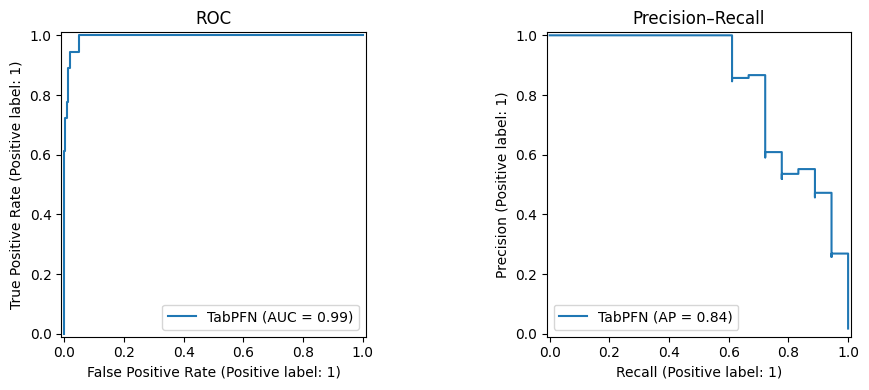

error uploading: HTTPSConnectionPool(host='eu.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by NameResolutionError("HTTPSConnection(host='eu.i.posthog.com', port=443): Failed to resolve 'eu.i.posthog.com' ([Errno -3] Temporary failure in name resolution)"))


In [17]:
import os

from tabpfn import TabPFNClassifier

if not os.environ.get("TABPFN_TOKEN"):
    raise RuntimeError(
        "Missing TABPFN_TOKEN (required before .fit()). Run the cell above or export TABPFN_TOKEN in your shell."
    )


def _threshold_max_f1(
    y_true: np.ndarray, scores: np.ndarray, *, grid_points: int = 199
) -> tuple[float, float]:
    """Return (best_threshold, best_f1) for y_hat = (scores >= t). Positive class = 1."""
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.01, 0.99, grid_points):
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


_tabpfn_kw = dict(
    n_estimators=N_ESTIMATORS,
    device=DEVICE,
    ignore_pretraining_limits=IGNORE_PRETRAINING_LIMITS,
    balance_probabilities=BALANCE_PROBABILITIES,
)

if DECISION_THRESHOLD is not None:
    HOLDOUT_THRESHOLD = float(DECISION_THRESHOLD)
    print(f"Using fixed DECISION_THRESHOLD={HOLDOUT_THRESHOLD} (TabPFN-style thresholding)")
    clf = TabPFNClassifier(random_state=RANDOM_STATE, **_tabpfn_kw)
    clf.fit(X_train, y_train)
else:
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train,
        y_train,
        test_size=THRESHOLD_VAL_FRACTION,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
    clf_tune = TabPFNClassifier(random_state=RANDOM_STATE, **_tabpfn_kw)
    clf_tune.fit(X_fit, y_fit)
    val_prob = clf_tune.predict_proba(X_val)[:, 1]
    HOLDOUT_THRESHOLD, val_f1 = _threshold_max_f1(y_val, val_prob)
    print(
        f"Tuned P(class=1) threshold on stratified val slice ({THRESHOLD_VAL_FRACTION:.0%} of train): "
        f"{HOLDOUT_THRESHOLD:.4f} (val F1={val_f1:.4f}), then refit on full train"
    )
    clf = TabPFNClassifier(random_state=RANDOM_STATE, **_tabpfn_kw)
    clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= HOLDOUT_THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(f"balance_probabilities={BALANCE_PROBABILITIES}  decision_threshold={HOLDOUT_THRESHOLD:.6f}")

metrics = {
    "accuracy": (y_pred == y_test).mean(),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "pr_auc": average_precision_score(y_test, y_prob),
    "decision_threshold": HOLDOUT_THRESHOLD,
}
for k, v in metrics.items():
    if k == "decision_threshold":
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v:.4f}")

pd.Series(metrics).to_csv(tabpfn_result_path("tabpfn_holdout_metrics.csv"))
joblib.dump(
    {
        "feature_names": feature_names,
        "use_raw_features": USE_RAW_FEATURES,
        "decision_threshold": HOLDOUT_THRESHOLD,
        "balance_probabilities": BALANCE_PROBABILITIES,
        "result_tag": TABPFN_RESULT_TAG,
    },
    tabpfn_result_path("tabpfn_run_meta.joblib"),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name="TabPFN")
axes[0].set_title("ROC")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="TabPFN")
axes[1].set_title("Precision–Recall")
plt.tight_layout()
plt.savefig(tabpfn_result_path("tabpfn_roc_pr.png"), dpi=150)
print("Wrote", tabpfn_result_path("tabpfn_holdout_metrics.csv"))
print("Wrote", tabpfn_result_path("tabpfn_run_meta.joblib"))
print("Wrote", tabpfn_result_path("tabpfn_roc_pr.png"))
plt.show()

## 6. Optional: stratified cross-validation (slow)

Each fold refits TabPFN on the training portion only. Use **`X_train_before_smote`** so SMOTE is not applied inconsistently across folds unless you intentionally resample inside a pipeline yourself.

In [10]:
if RUN_TABPFN_CV:
    skf = StratifiedKFold(
        n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    pr_aucs, roc_aucs, f1s = [], [], []
    for fold, (tr_idx, va_idx) in enumerate(
        skf.split(X_train_before_smote, y_train_before_smote), start=1
    ):
        X_tr, X_va = X_train_before_smote[tr_idx], X_train_before_smote[va_idx]
        y_tr, y_va = y_train_before_smote[tr_idx], y_train_before_smote[va_idx]
        m = TabPFNClassifier(
            n_estimators=N_ESTIMATORS,
            device=DEVICE,
            ignore_pretraining_limits=IGNORE_PRETRAINING_LIMITS,
            balance_probabilities=BALANCE_PROBABILITIES,
            random_state=RANDOM_STATE + fold,
        )
        m.fit(X_tr, y_tr)
        p = m.predict_proba(X_va)[:, 1]
        _thr = globals().get("HOLDOUT_THRESHOLD", 0.5)
        pred = (p >= _thr).astype(int)
        pr_aucs.append(average_precision_score(y_va, p))
        roc_aucs.append(roc_auc_score(y_va, p))
        f1s.append(f1_score(y_va, pred, zero_division=0))
        print(
            f"Fold {fold}/{CV_SPLITS}  PR-AUC={pr_aucs[-1]:.4f}  "
            f"ROC-AUC={roc_aucs[-1]:.4f}  F1={f1s[-1]:.4f}"
        )
    summary = pd.DataFrame(
        {
            "pr_auc_mean": np.mean(pr_aucs),
            "pr_auc_std": np.std(pr_aucs),
            "roc_auc_mean": np.mean(roc_aucs),
            "roc_auc_std": np.std(roc_aucs),
            "f1_mean": np.mean(f1s),
            "f1_std": np.std(f1s),
        },
        index=[0],
    )
    print(summary)
    summary.to_csv(tabpfn_result_path("tabpfn_cv_summary.csv"), index=False)
    print("Wrote", tabpfn_result_path("tabpfn_cv_summary.csv"))
else:
    print("Stratified CV skipped (set RUN_TABPFN_CV = True to enable).")

Fold 1/3  PR-AUC=0.8400  ROC-AUC=0.9832  F1=0.3459
Fold 2/3  PR-AUC=0.7018  ROC-AUC=0.9721  F1=0.2821
Fold 3/3  PR-AUC=0.7823  ROC-AUC=0.9835  F1=0.3385
   pr_auc_mean  pr_auc_std  roc_auc_mean  roc_auc_std   f1_mean    f1_std
0     0.774666    0.056672      0.979583     0.005288  0.322126  0.028498
